In [1]:
import symlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import colormaps
import matplotlib.colors as mcolors
import scipy
from scipy import stats

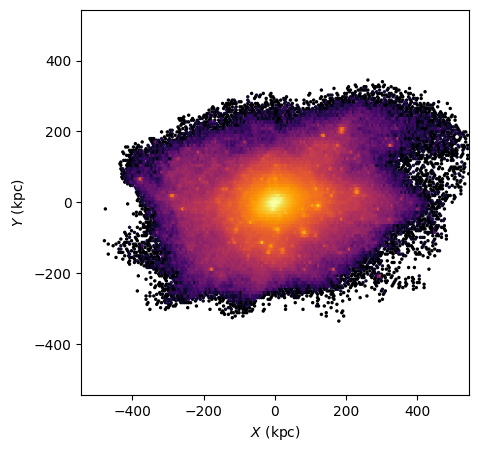

In [5]:
import matplotlib.pyplot as plt
import symlib
import matplotlib as mpl

try:
    import palette
    palette.configure(True)
except:
    pass

## making a single particle map

fig, ax = plt.subplots(figsize=(5, 5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.05, hspace=0.05)

base_dir = "C:/Users/steph/Symphony"
suite_name = "SymphonyMilkyWay"
halo = "Halo023"

sim_dir = symlib.get_host_directory(base_dir, suite_name, halo)

rs, hist = symlib.read_rockstar(sim_dir)
    
host, sub = rs[0], rs[1]
lim = 2*host["rvir"][-1]

ax.set_ylabel(r"$Y\ ({\rm kpc})$")
ax.set_xlabel(r"$X\ ({\rm kpc})$")
sub_ls, host_ls = "-", ":"
sub_ls, host_ls = ":", "-"
#symlib.plot_circle(ax, host["x"][-1,0], host["x"][-1,1], host["rvir"][-1], c="white", ls=host_ls)
#symlib.plot_circle(ax, sub["x"][-1,0], sub["x"][-1,1], sub["rvir"][-1], c="white", ls=sub_ls)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

snapshot = 199
part = symlib.Particles(sim_dir)
p = part.read(snapshot)
hp, sp = p[0], p[1]

norm = mpl.colors.LogNorm(vmin=1, vmax=10000)
kwargs = {"extent": [-lim, lim, -lim, lim], "norm": norm, "cmap": "inferno", "gridsize": 200}
ax.hexbin(hp["x"][:,0], hp["x"][:,1], **kwargs)

plt.show()

150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


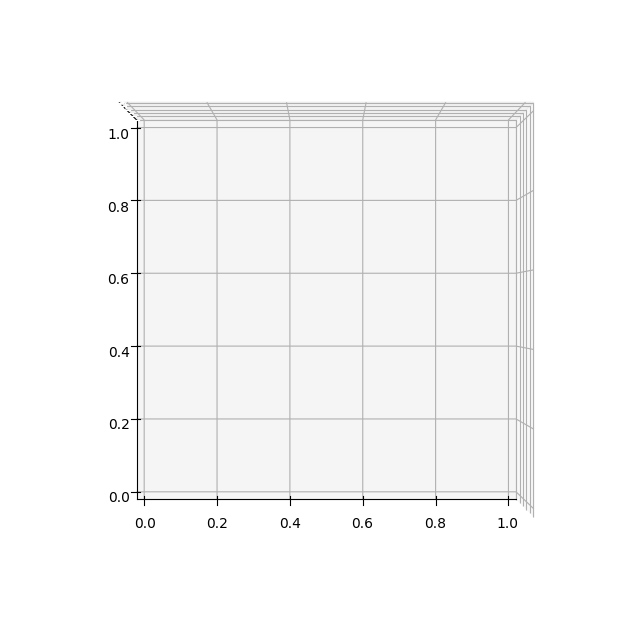

In [13]:
## making the density map animation

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

base_dir = "C:/Users/steph/Symphony"
suite_name = "SymphonyMilkyWay"
halo = "Halo023"
image_directory = "3d_density_gif/*.png"
output_gif_path = "3d_density_animation_above.gif"

sim_dir = symlib.get_host_directory(base_dir, suite_name, halo)
rs, hist = symlib.read_rockstar(sim_dir)

snapshots = np.arange(150, 200, 1)

for snap in snapshots:
    print(snap)

    part = symlib.Particles(sim_dir)
    p = part.read(snap)
    
    x = p[0]["x"][:, 0]
    y = p[0]["x"][:, 1]
    z = p[0]["x"][:, 2]
    
    box_length = 5
    
    x_bin = np.floor(x/box_length).astype(np.int32)
    y_bin = np.floor(y/box_length).astype(np.int32)
    z_bin = np.floor(z/box_length).astype(np.int32)
    n_points = len(x)
    
    bins = {}
    
    for i in range(n_points):
        coord = (x_bin[i], y_bin[i], z_bin[i])
        if coord not in bins:
            bins[coord] = []
        bins[coord].append((x[i], y[i], z[i]))
    
    x_plot1 = []
    y_plot1 = []
    z_plot1 = []
    colors = []
    max_count = 0
    
    for k, v in bins.items():
        for x, y, z in v:
            x_plot1.append(x)
            y_plot1.append(y)
            z_plot1.append(z)
    
        # set the color
        count = np.log10(len(v))
        colors.extend([count] * len(v))
        max_count = max(max_count, count)
    
    x_plot = np.array(x_plot1)
    y_plot = np.array(y_plot1)
    z_plot = np.array(z_plot1)
    colors_plot = np.array(colors)/max_count
    
    ax.view_init(elev=90, azim = -90)  ## viewing XY plane
    ax.scatter(x_plot[::25], y_plot[::25], z_plot[::25], s = 0.1, alpha = 0.1, c = colors_plot[::25], cmap = "plasma")
    ax.set_xlabel('X [kpc]')
    ax.set_ylabel('Y [kpc]')

    ax.grid(False)
    # Change the z-axis spine color (the line itself)
    ax.spines['left'].set_color('white')  # The z-axis is typically associated with the 'left' spine in a 3D view
    
    # Change the z-axis tick labels color
    ax.tick_params(axis='z', colors='white')
    
    # Change the z-axis label color
    ax.set_zlabel('Z-Axis Label', color='white')
    

    output_directory = "3d_density"
    filename = f"3d_density_render_{snap}.png"
    
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        
    full_path = os.path.join(output_directory, filename)
    plt.savefig(full_path, dpi = 100, facecolor = 'white')
    
    plt.cla()

In [14]:
from matplotlib.animation import FuncAnimation, PillowWriter
from PIL import Image, ImageSequence
import glob
import re

image_directory = "3d_density/*.png"
output_gif_path = "3d_density_animation_above.gif"

image_paths = glob.glob(image_directory)
image_paths = sorted(glob.glob(image_directory), key=lambda x: int(re.search(r"(\d+)", x).group()))
 
# Load images 
images = []
for path in image_paths:
    img = Image.open(path)
    images.append(img)

if images:
    images[0].save(output_gif_path, save_all=True, append_images=images[1:], duration = 100, loop=0)
    print(f"GIF created and saved at {output_gif_path}")
else:
    print("No images found in the specified directory.")

GIF created and saved at 3d_density_animation_above.gif
